# SC2001 Project 2: Dijkstra's Algorithm
(a) Adjacency matrix + array priority queue  
(b) Adjacency lists + minimizing heap  
(c) Comparison

Run all cells top to bottom.

In [1]:
import random
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
INF = sys.maxsize
STATS = {"decreaseKey": 0}   # counts decreaseKey calls in (b)

## 1. Graph generator
Directed graph with `n` vertices and `e` edges, positive weights 1 to 100.  
In the matrix, `0` means no edge. A random tree rooted at vertex 0 is built first, so every vertex is reachable from source 0.  
`convert_to_adjList` turns the **same** matrix into adjacency lists, so (a) and (b) run on identical graphs.

In [2]:
def graph_generator(n, e, seed=None):
    rng = random.Random(seed)
    max_e = n * (n - 1)
    if not (n - 1 <= e <= max_e):
        raise ValueError(f"e must be between {n-1} and {max_e}")

    # generate our n by n matrix (0 = no edge)
    matrix = [[0 for i in range(n)] for j in range(n)]

    # connectivity: random tree rooted at 0 (uses n-1 edges)
    order = list(range(1, n))
    rng.shuffle(order)
    order = [0] + order
    for i in range(1, n):
        parent = order[rng.randrange(i)]
        matrix[parent][order[i]] = rng.randint(1, 100)
    e -= (n - 1)

    if e > (max_e - (n - 1)) // 2:
        # dense: pick directly from the empty pairs (random guessing would stall)
        empty = [(a, b) for a in range(n) for b in range(n)
                 if a != b and matrix[a][b] == 0]
        for a, b in rng.sample(empty, e):
            matrix[a][b] = rng.randint(1, 100)
    else:
        # sparse: random pairs, skip self loops and existing edges
        while e != 0:
            a = rng.randint(0, n - 1)
            b = rng.randint(0, n - 1)
            if a != b and matrix[a][b] == 0:
                matrix[a][b] = rng.randint(1, 100)   # weight assigned directly
                e -= 1
    return matrix


def convert_to_adjList(graph, n):
    adjList = [[] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if graph[i][j] != 0:
                adjList[i].append((j, graph[i][j]))
    return adjList


def print_adjList(adjList):
    for i in range(len(adjList)):
        print(i, end="")
        for j in adjList[i]:
            print(" -> {}".format(j), end="")
        print()


# small demo
demo = graph_generator(5, 8, seed=1)
for row in demo:
    print(row)
print_adjList(convert_to_adjList(demo, 5))

[0, 0, 0, 4, 16]
[0, 0, 0, 0, 14]
[3, 0, 0, 0, 0]
[0, 0, 27, 0, 0]
[90, 98, 0, 61, 0]
0 -> (3, 4) -> (4, 16)
1 -> (4, 14)
2 -> (0, 3)
3 -> (2, 27)
4 -> (0, 90) -> (1, 98) -> (3, 61)


## 2. Part (a): Adjacency matrix + array
The array `dist` acts as the priority queue: each round scans it for the unvisited vertex with the smallest distance.

In [3]:
def dijkstra_matrix_array(graph, source):
    V = len(graph)
    dist = [INF] * V

    # initialise visited list
    visited = [False] * V
    dist[source] = 0

    for _ in range(V):
        # find vertex with min dist
        u = -1
        min_dist = INF
        for cand in range(V):
            if not visited[cand] and dist[cand] < min_dist:
                min_dist = dist[cand]
                u = cand

        # if no reachable unvisited => break
        if u == -1:
            break

        visited[u] = True

        # adj matrix relaxation steps
        for v in range(V):
            weight = graph[u][v]
            if weight != 0 and not visited[v]:
                if dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight

    return dist

print(dijkstra_matrix_array(demo, 0))

[0, 114, 31, 4, 16]


### Theoretical analysis (a)
- The outer loop runs |V| times (each vertex extracted once).
- **Extract-min:** linear scan of the `dist` array, O(|V|) each, so O(|V|²) in total.
- **Relaxation:** for the extracted vertex u, the whole row `graph[u][0..V-1]` is scanned to find neighbours, O(|V|) each, so O(|V|²) in total. Absent edges are still checked.
- **Total: O(|V|²)** in the best, average and worst case. |E| does not appear: the matrix row scan costs |V| no matter how many edges exist.

## 3. Part (b): Adjacency lists + minimizing heap
Custom binary min-heap with `decreaseKey` and a `pos` array tracking each vertex's index in the heap.

In [4]:
class Heap():
    def __init__(self):
        self.array = []
        self.size = 0
        self.pos = []

    def newMinHeapNode(self, v, dist):
        return [v, dist]

    def swapMinHeapNode(self, a, b):
        self.array[a], self.array[b] = self.array[b], self.array[a]

    def minHeapify(self, index):
        smallest = index
        left = 2 * index + 1
        right = 2 * index + 2

        if left < self.size and self.array[left][1] < self.array[smallest][1]:
            smallest = left
        if right < self.size and self.array[right][1] < self.array[smallest][1]:
            smallest = right

        # nodes need to be swapped if index is not smallest
        if smallest != index:
            self.pos[self.array[smallest][0]] = index
            self.pos[self.array[index][0]] = smallest
            self.swapMinHeapNode(index, smallest)
            self.minHeapify(smallest)

    def extractMin(self):
        if self.isEmpty():
            return None

        # store root, move last node to root
        root = self.array[0]
        lastNode = self.array[self.size - 1]
        self.array[0] = lastNode
        self.array[self.size - 1] = root

        # update positions
        self.pos[lastNode[0]] = 0
        self.pos[root[0]] = self.size - 1

        # reduce heap size and heapify
        self.size -= 1
        self.minHeapify(0)
        return root

    def isEmpty(self):
        return self.size == 0

    def decreaseKey(self, v, dist):
        i = self.pos[v]
        self.array[i][1] = dist

        # travel up while smaller than parent
        while i > 0 and self.array[i][1] < self.array[(i - 1) // 2][1]:
            self.pos[self.array[i][0]] = (i - 1) // 2
            self.pos[self.array[(i - 1) // 2][0]] = i
            self.swapMinHeapNode(i, (i - 1) // 2)
            i = (i - 1) // 2

    def isInMinheap(self, v):
        return self.pos[v] < self.size


def dijkstra_list_minheap(adj, source):
    V = len(adj)
    dist = []
    minHeap = Heap()

    for v in range(V):
        dist.append(INF)
        minHeap.array.append(minHeap.newMinHeapNode(v, dist[v]))
        minHeap.pos.append(v)

    minHeap.size = V
    dist[source] = 0
    minHeap.decreaseKey(source, dist[source])

    while not minHeap.isEmpty():
        # extract the vertex with min dist
        u = minHeap.extractMin()[0]

        # unreachable vertices left: stop
        if dist[u] == INF:
            break

        # traverse only u's actual neighbours
        for v, w in adj[u]:
            if minHeap.isInMinheap(v) and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                STATS["decreaseKey"] += 1
                minHeap.decreaseKey(v, dist[v])

    return dist

print(dijkstra_list_minheap(convert_to_adjList(demo, 5), 0))

[0, 114, 31, 4, 16]


### Theoretical analysis (b)
- **Building the heap:** all |V| vertices inserted with key ∞: O(|V|).
- **Extract-min:** |V| times, each O(log |V|) (move last node to root, heapify down), so O(|V| log |V|).
- **Relaxation:** each vertex's adjacency list is scanned once, so |E| edges are examined in total. Each successful relaxation calls `decreaseKey`, O(log |V|) (bubble up). Worst case every edge relaxes: O(|E| log |V|).
- **Total: O((|V| + |E|) log |V|)**, which is O(|E| log |V|) for a connected graph.
- Sparse graph (|E| ≈ |V|): O(|V| log |V|). Dense graph (|E| ≈ |V|²): O(|V|² log |V|).

## 4. Correctness check
Both implementations must give identical distances on the same graphs.

In [5]:
ok = True
for trial in range(30):
    n = random.randint(5, 150)
    e = random.randint(n - 1, n * (n - 1))
    m = graph_generator(n, e, seed=trial)
    if dijkstra_matrix_array(m, 0) != dijkstra_list_minheap(convert_to_adjList(m, n), 0):
        ok = False
        print("MISMATCH at trial", trial, n, e)
print("Both implementations agree:", ok)

Both implementations agree: True


## 5. Experiments
`time_both` times only the Dijkstra call (graph generation and conversion are excluded), averaged over `REPEATS` random graphs.

- **Experiment 1:** fix |V| = 1000, vary |E| from a tree (|V|-1) to the complete graph.
- **Experiment 2:** vary |V| at three densities:
  - sparse: |E| = 5|V|
  - average: |E| = |V|(|V|-1)/10 (10% of all possible edges)
  - dense: |E| = |V|(|V|-1)/2 (50% of all possible edges)

In [6]:
REPEATS = 5

def time_both(n, e):
    ta = tb = 0.0
    for r in range(REPEATS):
        m = graph_generator(n, e, seed=SEED + r)
        adj = convert_to_adjList(m, n)

        t0 = time.perf_counter()
        dijkstra_matrix_array(m, 0)
        ta += time.perf_counter() - t0

        t0 = time.perf_counter()
        dijkstra_list_minheap(adj, 0)
        tb += time.perf_counter() - t0
    return ta / REPEATS, tb / REPEATS

In [7]:
# Experiment 1: fixed V, vary E
V_FIXED = 1000
max_e = V_FIXED * (V_FIXED - 1)
E_list = [V_FIXED - 1, 2*V_FIXED, 5*V_FIXED, 10*V_FIXED, 25*V_FIXED, 50*V_FIXED,
          100*V_FIXED, 200*V_FIXED, 400*V_FIXED, 700*V_FIXED, max_e]

rows = []
for e in E_list:
    ta, tb = time_both(V_FIXED, e)
    rows.append({"V": V_FIXED, "E": e, "array": ta, "heap": tb})
    print(f"V={V_FIXED} E={e:>7}  array={ta:.4f}s  heap={tb:.4f}s")

exp1 = pd.DataFrame(rows)
exp1.to_csv("exp1_vary_E.csv", index=False)

V=1000 E=    999  array=0.0543s  heap=0.0035s
V=1000 E=   2000  array=0.0539s  heap=0.0044s
V=1000 E=   5000  array=0.0515s  heap=0.0044s
V=1000 E=  10000  array=0.0505s  heap=0.0049s
V=1000 E=  25000  array=0.0513s  heap=0.0065s
V=1000 E=  50000  array=0.0513s  heap=0.0084s
V=1000 E= 100000  array=0.0537s  heap=0.0124s
V=1000 E= 200000  array=0.0567s  heap=0.0191s
V=1000 E= 400000  array=0.0625s  heap=0.0322s
V=1000 E= 700000  array=0.0645s  heap=0.0491s
V=1000 E= 999000  array=0.0683s  heap=0.0673s


In [8]:
# Experiment 2: vary V at sparse, average and dense densities
V_list = [100, 250, 500, 750, 1000, 1250, 1500, 2000]

rows = []
for n in V_list:
    for density, e in [("sparse", 5 * n), ("average", n * (n - 1) // 10), ("dense", n * (n - 1) // 2)]:
        ta, tb = time_both(n, e)
        rows.append({"V": n, "E": e, "density": density, "array": ta, "heap": tb})
        print(f"{density:7} V={n:>5} E={e:>8}  array={ta:.4f}s  heap={tb:.4f}s")

exp2 = pd.DataFrame(rows)
exp2.to_csv("exp2_vary_V.csv", index=False)

sparse  V=  100 E=     500  array=0.0005s  heap=0.0003s
average V=  100 E=     990  array=0.0005s  heap=0.0003s
dense   V=  100 E=    4950  array=0.0006s  heap=0.0006s
sparse  V=  250 E=    1250  array=0.0030s  heap=0.0008s
average V=  250 E=    6225  array=0.0031s  heap=0.0012s
dense   V=  250 E=   31125  array=0.0037s  heap=0.0029s
sparse  V=  500 E=    2500  array=0.0121s  heap=0.0018s
average V=  500 E=   24950  array=0.0130s  heap=0.0039s
dense   V=  500 E=  124750  array=0.0161s  heap=0.0107s
sparse  V=  750 E=    3750  array=0.0288s  heap=0.0032s
average V=  750 E=   56175  array=0.0289s  heap=0.0076s
dense   V=  750 E=  280875  array=0.0355s  heap=0.0222s
sparse  V= 1000 E=    5000  array=0.0506s  heap=0.0044s
average V= 1000 E=   99900  array=0.0540s  heap=0.0118s
dense   V= 1000 E=  499500  array=0.0633s  heap=0.0365s
sparse  V= 1250 E=    6250  array=0.0789s  heap=0.0056s
average V= 1250 E=  156125  array=0.0824s  heap=0.0170s
dense   V= 1250 E=  780625  array=0.1004s  heap=

## 6. Plots
Dashed lines are the theoretical curves, scaled by a least-squares constant so they line up with the measured times. Time is in milliseconds.

In [9]:
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.grid": True, "grid.alpha": 0.3, "legend.frameon": False})
BLUE, ORANGE = "#1f77b4", "#ff7f0e"
DENS_COL = {"sparse": "#2ca02c", "average": "#9467bd", "dense": "#d62728"}
DENSITY_TEXT = {"sparse": "|E| = 5|V|",
                "average": "|E| = 10% of all possible edges",
                "dense": "|E| = 50% of all possible edges"}
MS = 1000   # seconds -> milliseconds

def fit(t, f):
    # best c in t ≈ c * f (least squares through origin)
    t, f = np.asarray(t, float), np.asarray(f, float)
    return (t @ f) / (f @ f)

def heap_theory(V, E):
    V, E = np.asarray(V, float), np.asarray(E, float)
    return (V + E) * np.log2(V)

def thousands(ax):
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:g}k" if x else "0"))

### Figure 1. Part (a): empirical vs theoretical O(|V|²)

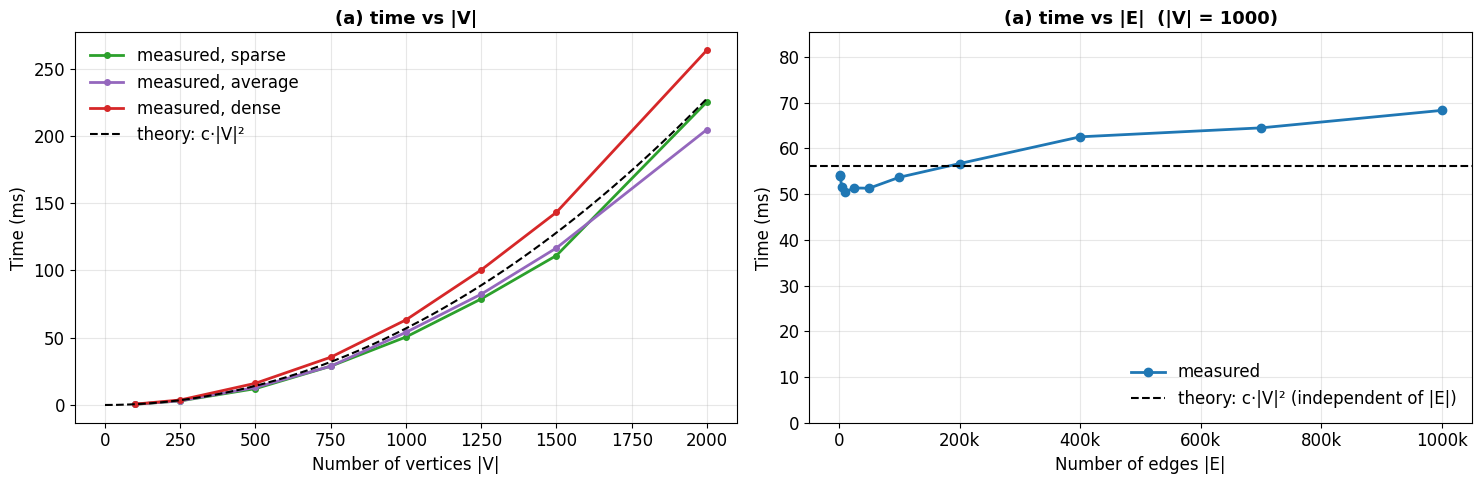

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# time vs |V|
for density in ["sparse", "average", "dense"]:
    d = exp2[exp2.density == density]
    ax[0].plot(d.V, d.array * MS, "o-", color=DENS_COL[density], lw=2, ms=4, label=f"measured, {density}")
Vs = np.linspace(0, exp2.V.max(), 200)
c = fit(exp2.array, exp2.V ** 2)
ax[0].plot(Vs, c * Vs ** 2 * MS, "--", color="black", lw=1.5, label="theory: c·|V|²")
ax[0].set(title="(a) time vs |V|", xlabel="Number of vertices |V|", ylabel="Time (ms)")
ax[0].legend(loc="upper left")

# time vs |E| at fixed |V|
ax[1].plot(exp1.E, exp1.array * MS, "o-", color=BLUE, lw=2, label="measured")
c = fit(exp1.array, np.full(len(exp1), V_FIXED ** 2))
ax[1].axhline(c * V_FIXED ** 2 * MS, ls="--", color="black", lw=1.5, label="theory: c·|V|² (independent of |E|)")
ax[1].set(title=f"(a) time vs |E|  (|V| = {V_FIXED})", xlabel="Number of edges |E|", ylabel="Time (ms)",
          ylim=(0, exp1.array.max() * MS * 1.25))
thousands(ax[1]); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

**Observations (a).**
- Time vs |V| follows the c·|V|² curve at every density, as predicted.
- Time vs |E| is roughly flat, but not perfectly: it rises slightly as |E| grows, and dense graphs sit slightly above sparse ones in the left plot. Each existing edge adds a comparison and an update inside the row scan, so the exact cost is Θ(|V|² + |E|). Since |E| ≤ |V|², this is still Θ(|V|²), and the |V|² row scan dominates.

### Figure 2. Part (b): empirical vs theoretical O((|V| + |E|) log |V|)

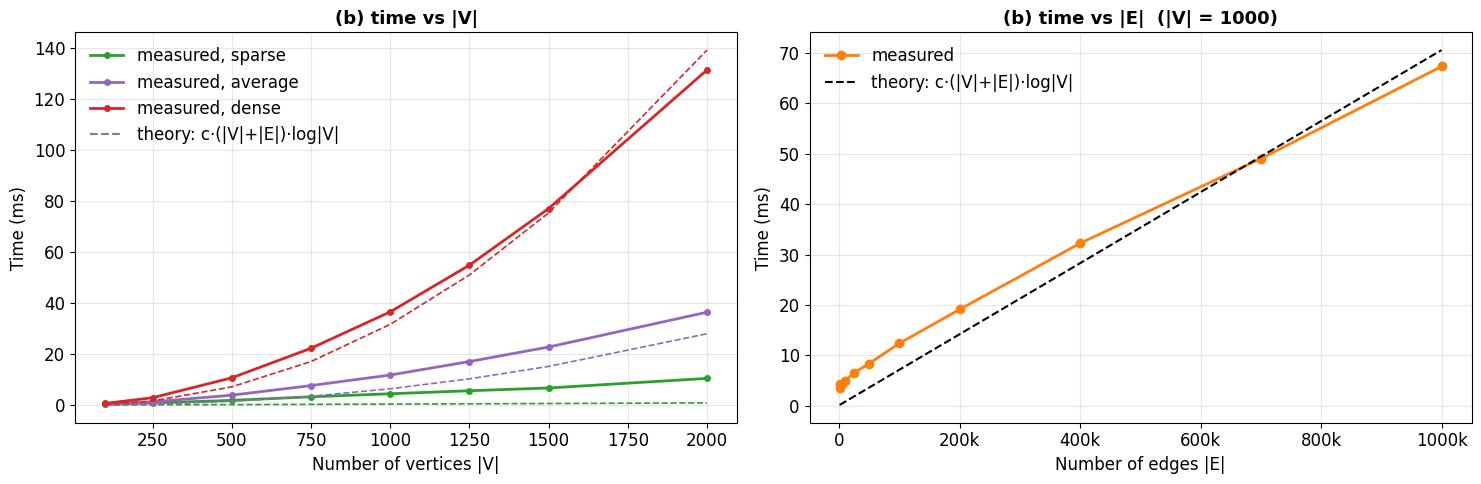

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# time vs |V|
c = fit(exp2.heap, heap_theory(exp2.V, exp2.E))   # one constant for all densities
for density in ["sparse", "average", "dense"]:
    d = exp2[exp2.density == density]
    ax[0].plot(d.V, d.heap * MS, "o-", color=DENS_COL[density], lw=2, ms=4, label=f"measured, {density}")
    ax[0].plot(d.V, c * heap_theory(d.V, d.E) * MS, "--", color=DENS_COL[density], lw=1.2)
ax[0].plot([], [], "--", color="grey", label="theory: c·(|V|+|E|)·log|V|")
ax[0].set(title="(b) time vs |V|", xlabel="Number of vertices |V|", ylabel="Time (ms)")
ax[0].legend(loc="upper left")

# time vs |E| at fixed |V|
f = heap_theory(exp1.V, exp1.E)
ax[1].plot(exp1.E, exp1.heap * MS, "o-", color=ORANGE, lw=2, label="measured")
ax[1].plot(exp1.E, fit(exp1.heap, f) * f * MS, "--", color="black", lw=1.5, label="theory: c·(|V|+|E|)·log|V|")
ax[1].set(title=f"(b) time vs |E|  (|V| = {V_FIXED})", xlabel="Number of edges |E|", ylabel="Time (ms)")
thousands(ax[1]); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

**Observations (b).** Time grows with both |V| and |E|, as predicted. However, the measurements do not track the bound exactly:
- Against |V| (left), one constant c is fitted across all three densities. The fitted curve matches the dense graphs, but sparse and average graphs run slower than it predicts. In other words, relative to the bound, dense graphs are cheaper per edge than sparse ones.
- Against |E| (right), the measured curve bends below the theoretical straight line.

Both come from the same cause. The bound O((|V| + |E|) log |V|) assumes **every** edge relaxation succeeds and calls `decreaseKey` (O(log |V|)). On random weights this rarely happens: once a vertex has a short tentative distance, most later edges into it fail the check and cost O(1). So the denser the graph, the smaller the fraction of edges that pay the log |V| cost. The table below counts the actual `decreaseKey` calls in Experiment 1.

In [12]:
rows = []
for e in E_list:
    m = graph_generator(V_FIXED, e, seed=SEED)
    STATS["decreaseKey"] = 0
    dijkstra_list_minheap(convert_to_adjList(m, V_FIXED), 0)
    rows.append({"E": e, "decreaseKey calls": STATS["decreaseKey"],
                 "fraction of E": round(STATS["decreaseKey"] / e, 4)})
pd.DataFrame(rows)

,E,decreaseKey calls,fraction of E
0,999,999,1.0000
1,2000,1088,0.5440
2,5000,1464,0.2928
3,10000,2008,0.2008
4,25000,2755,0.1102
5,50000,3283,0.0657
6,100000,3839,0.0384
7,200000,4173,0.0209
8,400000,4534,0.0113
9,700000,4623,0.0066


### Figure 3. Part (c): comparing (a) and (b)
Same colours throughout: **blue = (a) array + adjacency matrix**, **orange = (b) min-heap + adjacency lists**.

#### Figure 3a. Time vs |V|, sparse graphs (|E| = 5|V|)

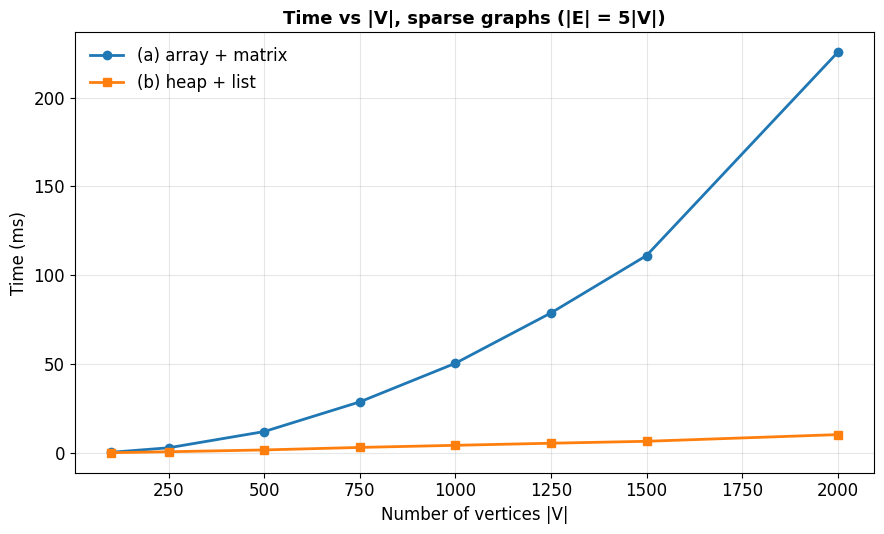

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
d = exp2[exp2.density == "sparse"]
ax.plot(d.V, d.array * MS, "o-", color=BLUE, lw=2, label="(a) array + matrix")
ax.plot(d.V, d.heap * MS, "s-", color=ORANGE, lw=2, label="(b) heap + list")
ax.set(title=f"Time vs |V|, sparse graphs ({DENSITY_TEXT['sparse']})",
       xlabel="Number of vertices |V|", ylabel="Time (ms)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

#### Figure 3b. Time vs |V|, average graphs (|E| = 10% of all possible edges)

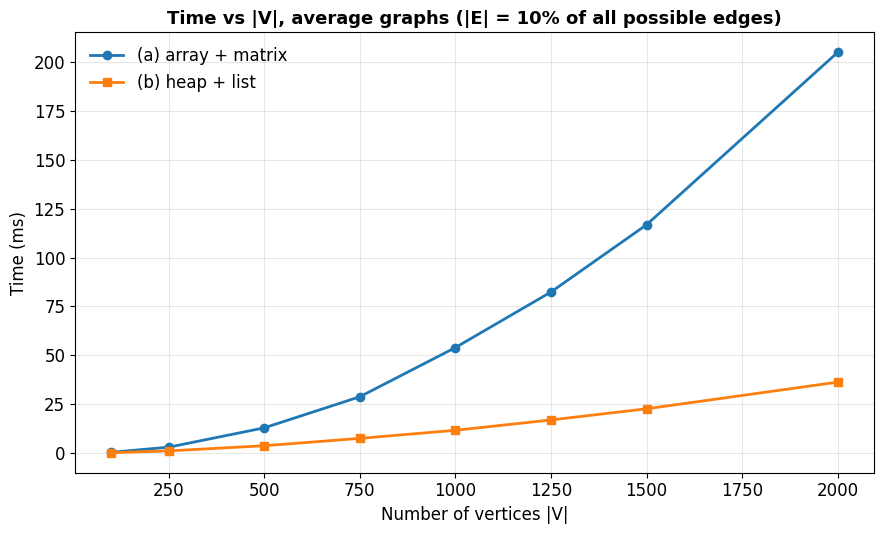

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
d = exp2[exp2.density == "average"]
ax.plot(d.V, d.array * MS, "o-", color=BLUE, lw=2, label="(a) array + matrix")
ax.plot(d.V, d.heap * MS, "s-", color=ORANGE, lw=2, label="(b) heap + list")
ax.set(title=f"Time vs |V|, average graphs ({DENSITY_TEXT['average']})",
       xlabel="Number of vertices |V|", ylabel="Time (ms)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

#### Figure 3c. Time vs |V|, dense graphs (|E| = 50% of all possible edges)

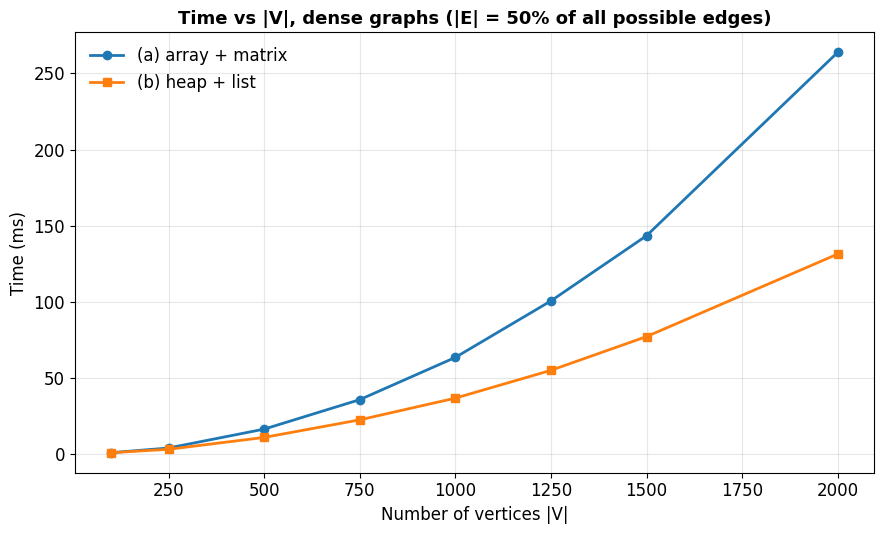

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
d = exp2[exp2.density == "dense"]
ax.plot(d.V, d.array * MS, "o-", color=BLUE, lw=2, label="(a) array + matrix")
ax.plot(d.V, d.heap * MS, "s-", color=ORANGE, lw=2, label="(b) heap + list")
ax.set(title=f"Time vs |V|, dense graphs ({DENSITY_TEXT['dense']})",
       xlabel="Number of vertices |V|", ylabel="Time (ms)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

#### Figure 3d. Time vs |E| at fixed |V| = 1000

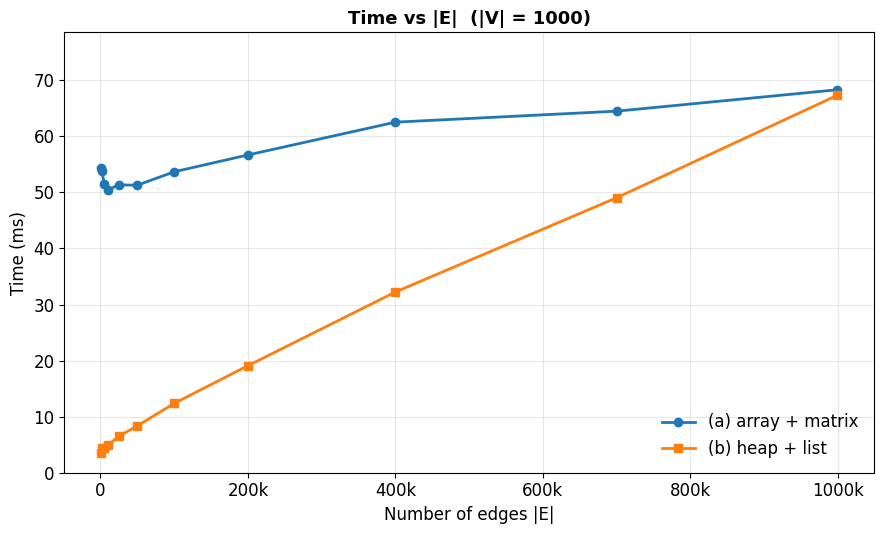

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(exp1.E, exp1.array * MS, "o-", color=BLUE, lw=2, label="(a) array + matrix")
ax.plot(exp1.E, exp1.heap * MS, "s-", color=ORANGE, lw=2, label="(b) heap + list")
ax.set(title=f"Time vs |E|  (|V| = {V_FIXED})", xlabel="Number of edges |E|", ylabel="Time (ms)",
       ylim=(0, max(exp1.array.max(), exp1.heap.max()) * MS * 1.15))
thousands(ax); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 7. Part (c) discussion

**Theory.** (a) costs Θ(|V|²) regardless of |E|. (b) costs O((|V| + |E|) log |V|).
- Sparse graphs (|E| = O(|V|)): (b) is O(|V| log |V|) vs Θ(|V|²) for (a), so **(b) is better**.
- Dense graphs (|E| = Θ(|V|²)): in the worst case (b) is O(|V|² log |V|) vs Θ(|V|²) for (a), so **(a) is better** by a log |V| factor.

**Empirical (Figures 3a to 3d).**
- Sparse and average graphs: (b) is much faster, and the gap widens as |V| grows, matching the theory.
- Dense graphs: (b) was still faster on our random graphs, and the two only meet near the complete graph (Figure 3d). This differs from the worst-case prediction because the worst case assumes every edge triggers a `decreaseKey`. On random weights only a small, shrinking fraction of edges do (see the table in Section 6), so most edges cost O(1) and (b) behaves closer to O(|E| + |V| log |V|). (a) cannot benefit from this, since it scans a full matrix row for every vertex no matter how many edges exist.
- As |E| approaches |V|², the O(|E|) edge scan in (b) catches up with the Θ(|V|²) row scan in (a) (Figure 3d). We did not test graphs where most relaxations succeed, but on such graphs (b) would also pay the extra heap work on most edges, so theory predicts (a) would overtake (b) there.

**Memory.** Adjacency matrix: Θ(|V|²) space even for sparse graphs. Adjacency lists: Θ(|V| + |E|).

**Conclusion.** (b) is the better general choice, especially for sparse graphs, which covers most real-world graphs such as road and social networks. (a) is only competitive on very dense graphs (close to complete), where its simpler O(1)-per-entry work and lack of heap overhead pay off, or when the graph is already stored as a matrix.